# Extended Figure 6. Spatial transcriptomic enhancement of the Human Heart Cell Atlas

6 panels of this figure are built below, one section each.

---

## Setup

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['retina']
import sys
sys.path[:0] = ["../src", "../figures/_lib", "../figures/ED6"]
from hhca.paths import TABLES, OUT
print('inputs :', TABLES)
print('outputs:', OUT)

inputs : /Volumes/Storage/hhca_spatial_tables
outputs: /Users/maiia.shulman/hhca_release_out


## ED6 B

ED6 B: schematic of the three spatial platforms (matplotlib boxes; geometry measured from ED_spatial_v2/panels/A_schematic.png, generator not archived).

Input:
- `none (drawn)`

Source: `figures/ED6/panel_b.py`

None


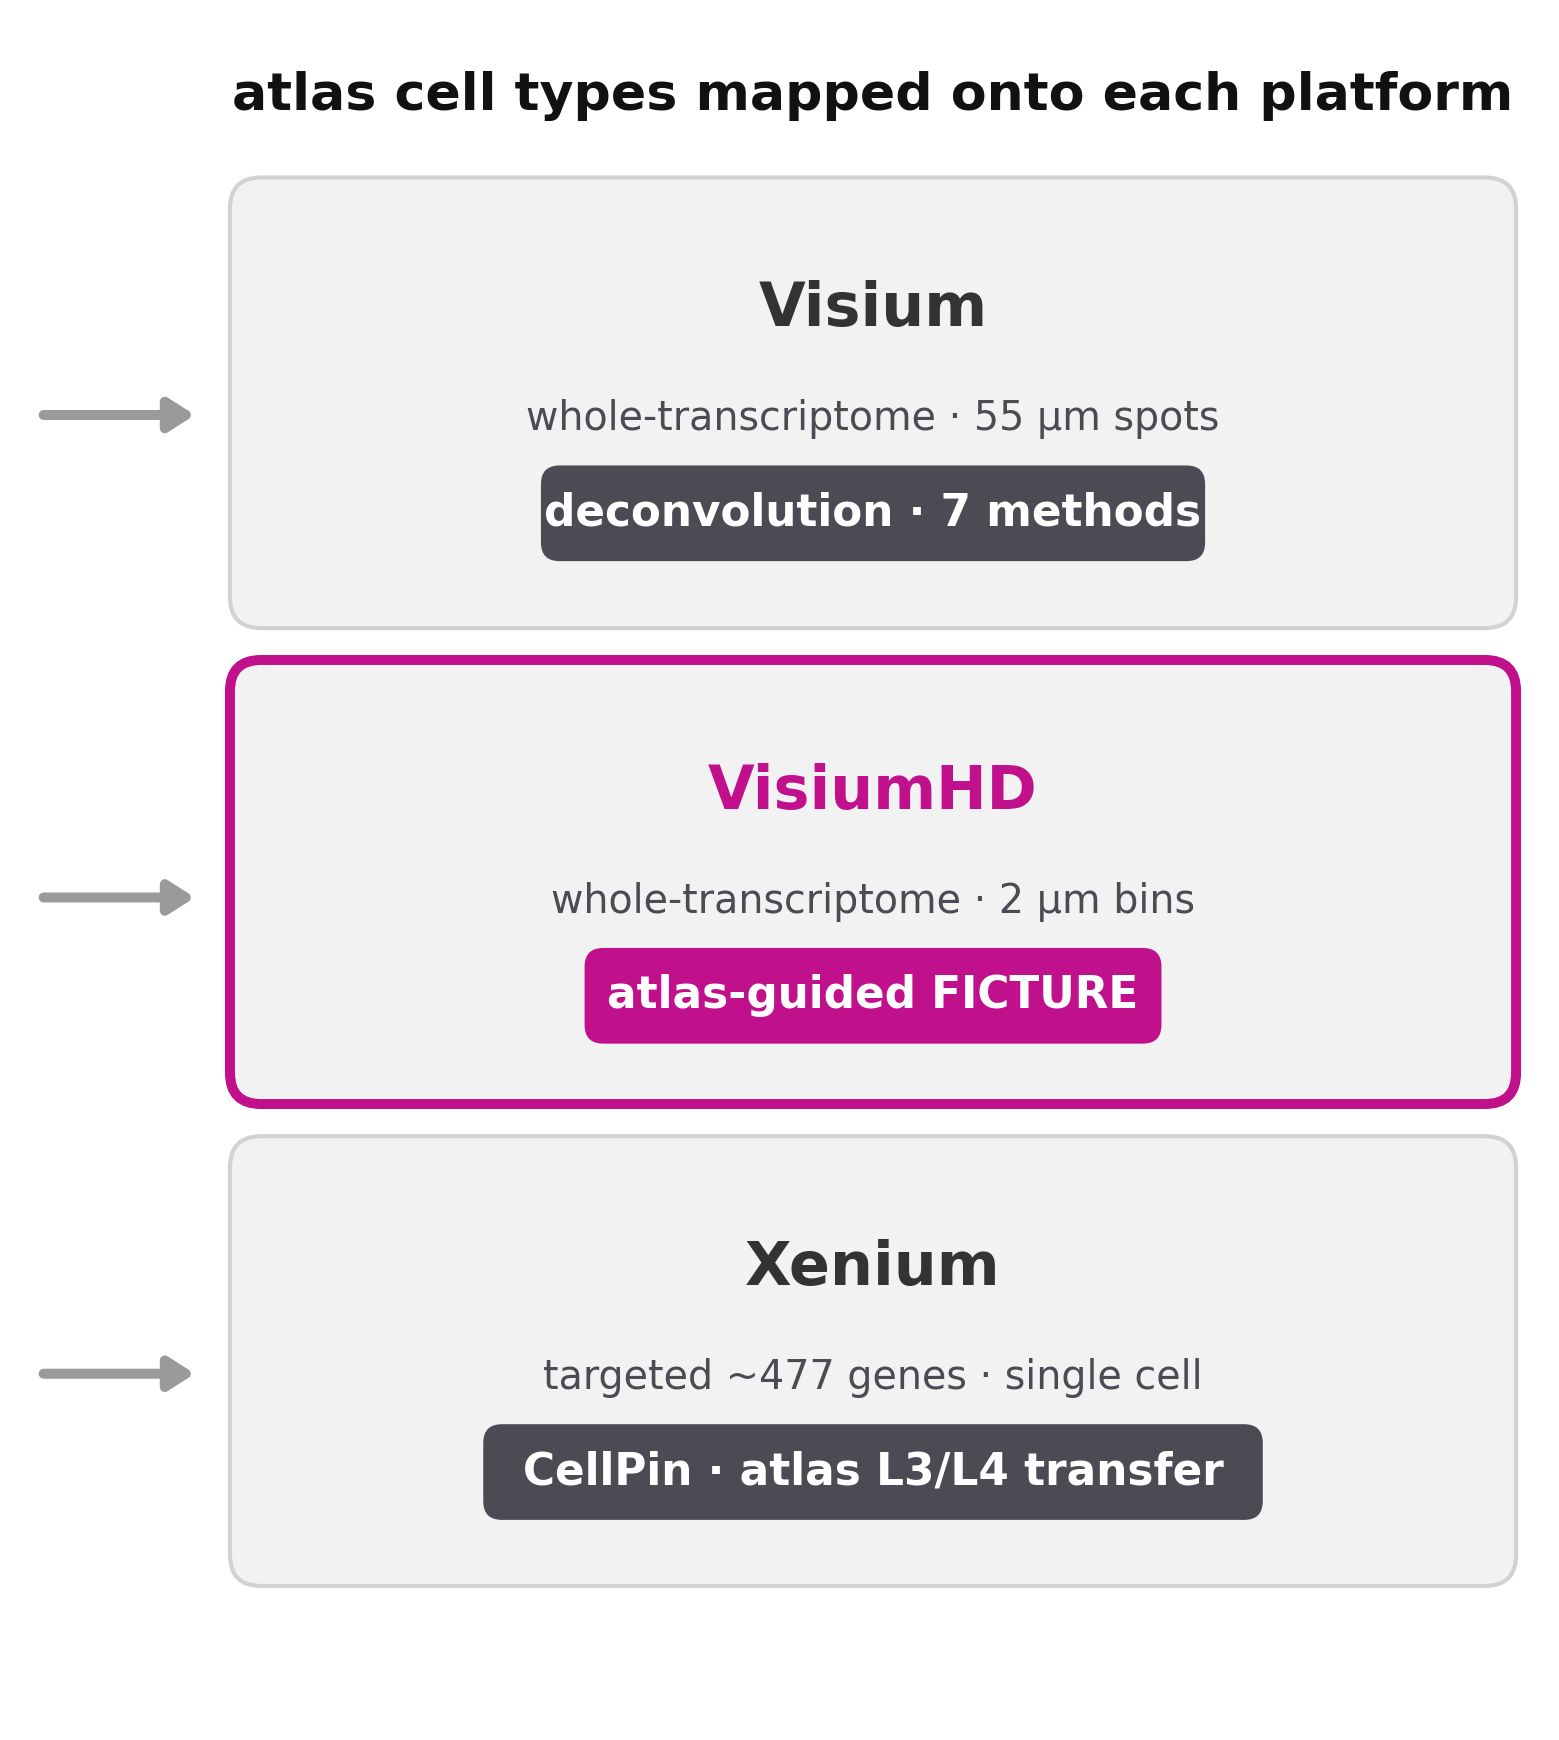

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

from hhca import style as H
from pubfig import save

H.apply()
MAG, INK, GREY, FILL, EDGE = "#C1108C", "#4B4B53", "#9A9A9A", "#F2F2F2", "#D2D2D2"
W, HT = 5.197, 5.8                      # A_schematic.pdf page, inches
plt.rcParams.update({"font.sans-serif": ["DejaVu Sans"], "savefig.bbox": None, "savefig.pad_inches": 0})
fig = plt.figure(figsize=(W, HT))
ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.text(0.56, 0.945, "atlas cell types mapped onto each platform", ha="center", va="center", fontsize=12.5,
        fontweight="bold", color="#111111")
X0, X1 = 0.1475, 0.9724
BOXES = [  # (y0, y1, name, name colour, subtitle, chip text, chip colour, chip half-width, frame colour, frame lw)
    (0.639, 0.898, "Visium", "#333333", "whole-transcriptome · 55 µm spots",
     "deconvolution · 7 methods", INK, 0.213, EDGE, 1.0),
    (0.3655, 0.6207, "VisiumHD", MAG, "whole-transcriptome · 2 µm bins",
     "atlas-guided FICTURE", MAG, 0.185, MAG, 2.4),
    (0.0885, 0.347, "Xenium", "#333333", "targeted ~477 genes · single cell",
     "CellPin · atlas L3/L4 transfer", INK, 0.250, EDGE, 1.0),
]
for y0, y1, name, ncol, sub, chip, ccol, chw, fcol, flw in BOXES:
    ax.add_patch(FancyBboxPatch((X0, y0), X1 - X0, y1 - y0, boxstyle="round,pad=0,rounding_size=0.02",
                                facecolor=FILL, edgecolor=fcol, linewidth=flw, mutation_aspect=W / HT))
    cx = (X0 + X1) / 2
    ax.text(cx, y1 - 0.076, name, ha="center", va="center", fontsize=14.5, fontweight="bold", color=ncol)
    ax.text(cx, y1 - 0.139, sub, ha="center", va="center", fontsize=9.5, color=INK)
    cy = y1 - 0.193
    ax.add_patch(FancyBboxPatch((cx - chw, cy - 0.0275), 2 * chw, 0.055, boxstyle="round,pad=0,rounding_size=0.012",
                                facecolor=ccol, edgecolor="none", mutation_aspect=W / HT))
    ax.text(cx, cy, chip, ha="center", va="center", fontsize=10.5, fontweight="bold", color="white")
    ay = y1 - 0.1365
    ax.add_patch(FancyArrowPatch((0.028, ay), (0.125, ay), arrowstyle="-|>,head_length=5,head_width=3.2",
                                 color=GREY, linewidth=2.4, shrinkA=0, shrinkB=0))
print(save(fig, "ED6", "b"))


## ED6 C

ED6 C: representative regions from the three spatial platforms at increasing resolution --

Input:
- `scanpy_analysis/standard_visium/deconv_benchmark/outputs/spotiphy/HHH2-LV-endo-1.csv.gz`
- `scanpy_analysis/standard_visium/atlas_deconv/tables/HHH2-LV-endo-1_L3_deconv.csv.gz`
- `scanpy_analysis/standard_visium/data/HHH2-LV-endo-1/spatial/scalefactors_json.json`
- `storage/Heart_ficture_2um_L3_h5ads/VS_CA_H0054LV_henricke_endo.h5ad`
- `storage/CMFLAG_fullmethod_realHE/VS_CA_H0054LV_henricke_endo_clean_bins.parquet`
- `scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin/annotation/xenium_annotated.h5ad`

Source: `figures/ED6/panel_c.py`

Visium FOV: 179 spots, pitch 110.0 px


VisiumHD FOV: 284,106 bins -> 243,203 clean (85.6%)
Xenium FOV: 1519 cells


None


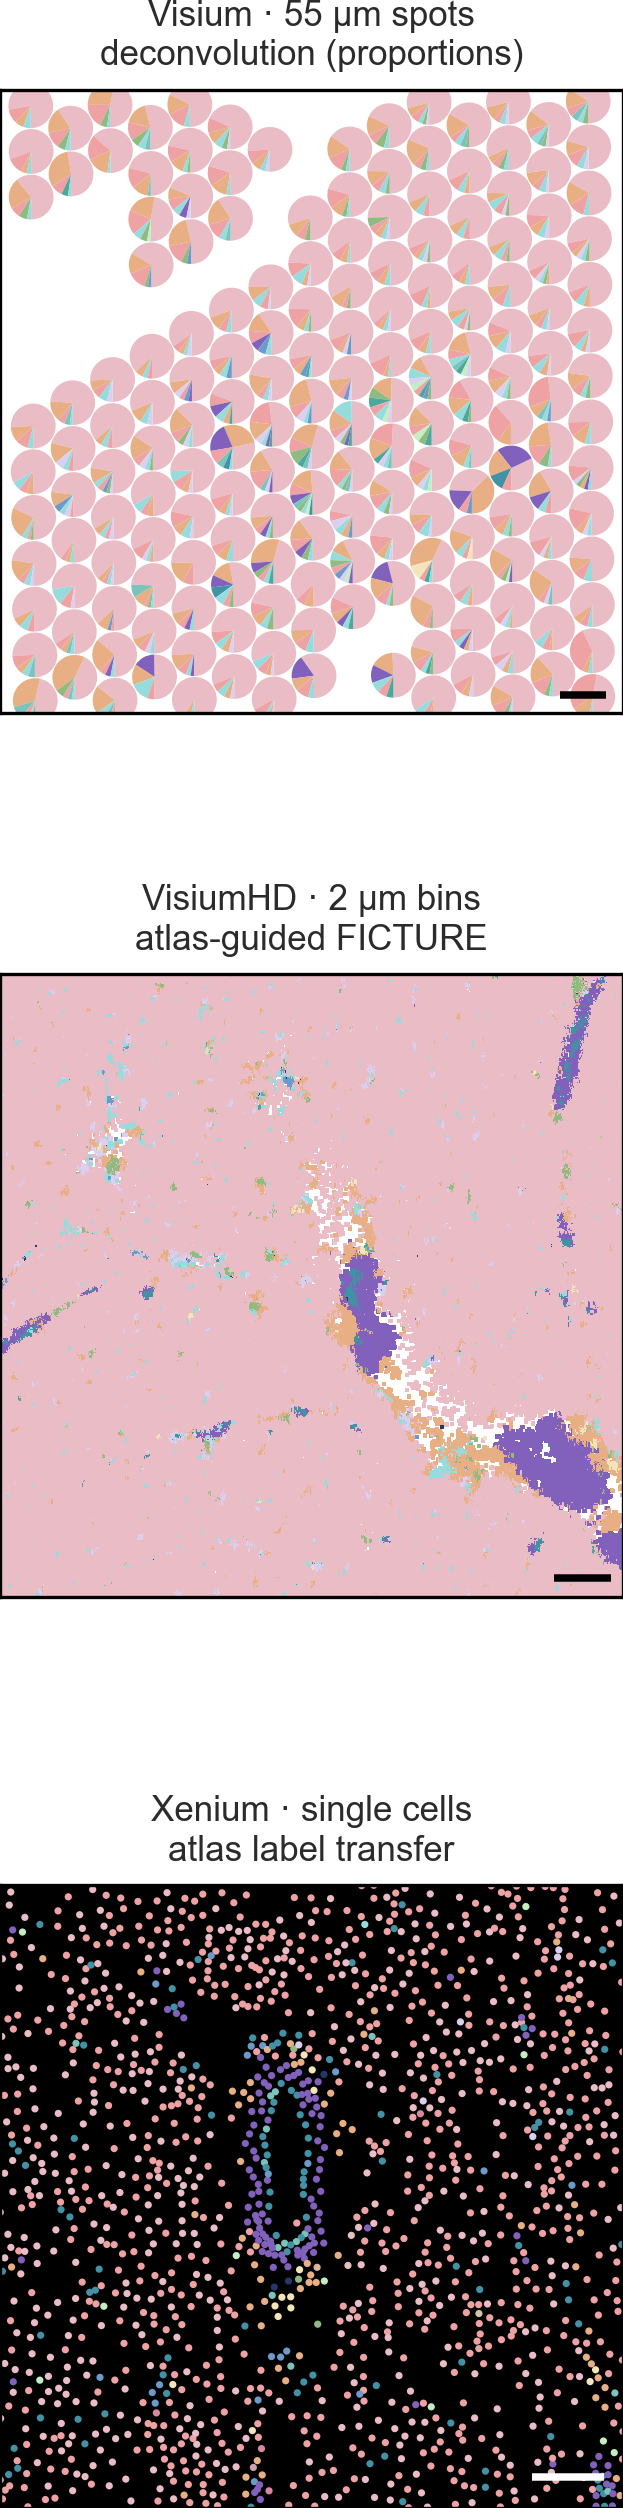

In [3]:
import json

import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Wedge
from scipy.spatial import cKDTree

from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()

# ---------------------------------------------------------------- row 1: Visium proportion pies
SV = f"{TABLES}/scanpy_analysis/standard_visium"
VSLIDE = "HHH2-LV-endo-1"
CELLTYPES = [
    "Adipocytes", "Arterial Endothelial cells", "Atrial Cardiomyocytes", "B cells",
    "Capillary Endothelial cells", "Dendritic cells", "Endocardial Endothelial Cells", "Epicardium",
    "Fibroblasts", "ILC", "Lymphatic Endothelial Cells", "Lymphoid Cells (Proliferating)", "Macrophages",
    "Mast cells", "Monocytes", "NK cells", "Neural Cells", "Pericytes", "Plasma Cells", "T cells",
    "Vascular Smooth Muscle cells", "Venous Endothelial cells", "Ventricular Cardiomyocytes"]
CM = ["Ventricular Cardiomyocytes", "Atrial Cardiomyocytes"]
COL = {ct: H.ct(ct) for ct in CELLTYPES}

coords = pd.read_csv(f"{SV}/atlas_deconv/tables/{VSLIDE}_L3_deconv.csv.gz", index_col=0)[["x", "y"]]
scalef = json.load(open(f"{SV}/data/{VSLIDE}/spatial/scalefactors_json.json"))["tissue_hires_scalef"]
props = pd.read_csv(f"{SV}/deconv_benchmark/outputs/spotiphy/{VSLIDE}.csv.gz", index_col=0)
props = props.reindex(columns=CELLTYPES).fillna(0.0)
props = props.div(props.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
xy = coords[["x", "y"]].values
pitch = float(np.median(cKDTree(xy).query(xy, k=2)[0][:, 1]))
radius = 0.5 * pitch * scalef * 0.98

non_cm = 1.0 - props.reindex(coords.index)[CM].sum(axis=1)
size_px = 1500.0
best, best_score = None, -np.inf
x_, y_ = coords.x.values, coords.y.values
for i in np.argsort(non_cm.values)[::-1][:150]:
    m = (np.abs(x_ - x_[i]) <= size_px / 2) & (np.abs(y_ - y_[i]) <= size_px / 2)
    if m.sum() < 30:
        continue
    score = non_cm.values[m].mean()
    if score > best_score:
        best_score, best = score, (x_[i], y_[i])
cx, cy = best
vx0, vx1, vy0, vy1 = cx - size_px / 2, cx + size_px / 2, cy - size_px / 2, cy + size_px / 2
vsub = coords[(coords.x.between(vx0, vx1)) & (coords.y.between(vy0, vy1))]
print(f"Visium FOV: {len(vsub)} spots, pitch {pitch:.1f} px")


def draw_pies(ax, sub, p, min_frac=0.02):
    wedges, fc = [], []
    for bc, (x, y) in sub[["x", "y"]].iterrows():
        q = p.loc[bc]
        q = q[q >= min_frac].sort_values(ascending=False)
        if q.empty:
            continue
        q = q / q.sum()
        theta = 90.0
        for ct, frac in q.items():
            span = 360.0 * float(frac)
            wedges.append(Wedge((x * scalef, y * scalef), radius, theta - span, theta))
            fc.append(COL[ct])
            theta -= span
    ax.add_collection(PatchCollection(wedges, facecolors=fc, linewidths=0))


# --------------------------------------------------------- row 2: VisiumHD 2 um atlas-guided FICTURE
HSLIDE = "VS_CA_H0054LV_henricke_endo"
H5AD = f"{TABLES}/storage/Heart_ficture_2um_L3_h5ads/{HSLIDE}.h5ad"
FLAGS = f"{TABLES}/storage/CMFLAG_fullmethod_realHE/{HSLIDE}_clean_bins.parquet"
FLAGCOLS = ["flag_cm_spillover", "flag_vsmc_spillover", "flag_spill_artEC", "flag_spill_venEC"]
HD_XY, HD_W = (3194.0, 2767.0), 1100.0

adata = ad.read_h5ad(H5AD, backed="r")
obs = adata.obs[["x_um", "y_um", "L3_label"]].copy()
adata.file.close()
obs["L3"] = obs.L3_label.astype(str)
half = HD_W / 2
hx0, hx1 = HD_XY[0] - half, HD_XY[0] + half
hy0, hy1 = HD_XY[1] - half, HD_XY[1] + half
obs = obs[(obs.x_um.between(hx0, hx1)) & (obs.y_um.between(hy0, hy1))].copy()


def bin_key(x, y):
    return np.round(x * 10).astype(np.int64) * 100_000_000 + np.round(y * 10).astype(np.int64)


flags = pd.read_parquet(FLAGS, columns=["X", "Y", "assign"] + FLAGCOLS)
flags = flags[flags.X.between(hx0 - 5, hx1 + 5) & flags.Y.between(hy0 - 5, hy1 + 5)]
flags["_k"] = bin_key(flags.X.to_numpy(), flags.Y.to_numpy())
per_bin = flags.groupby("_k", as_index=False).agg({**{c: "any" for c in FLAGCOLS}, "assign": "max"})
del flags
obs["_k"] = bin_key(obs.x_um.to_numpy(), obs.y_um.to_numpy())
obs = obs.merge(per_bin, on="_k", how="left")
obs[FLAGCOLS] = obs[FLAGCOLS].fillna(False).astype(bool)
obs["assign"] = obs["assign"].fillna(-1).astype(int)
clean = obs.loc[~obs[FLAGCOLS].any(axis=1) & (obs["assign"] != -1)].copy()
print(f"VisiumHD FOV: {len(obs):,} bins -> {len(clean):,} clean ({100 * len(clean) / max(len(obs), 1):.1f}%)")
hxs, hys, hlab = clean.x_um.to_numpy(), clean.y_um.to_numpy(), clean.L3.to_numpy()
hcol = np.array([H.ct(t) for t in hlab], dtype=object)

# --------------------------------------------------------------- row 3: Xenium single cells
CELLPIN = f"{TABLES}/scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin"
xa = ad.read_h5ad(f"{CELLPIN}/annotation/xenium_annotated.h5ad", backed="r")
xy_x = np.asarray(xa.obsm["spatial"], float)
fine = xa.obs.cellpin_fine.astype(str).to_numpy()   # already Level-3 atlas names in this (current) object
xa.file.close()
keep = np.ones(len(fine), dtype=bool)
# same vascular-niche ROI already highlighted in ED6 I's zoom (a representative, cell-dense field)
mx, my = 0.05 * np.ptp(xy_x[:, 0]), 0.05 * np.ptp(xy_x[:, 1])
XLIM = (xy_x[:, 0].min() - mx, xy_x[:, 0].max() + mx)
YLIM = (xy_x[:, 1].max() + my, xy_x[:, 1].min() - my)
AX_MAIN = (17.0017334906, 7.2, 179.1165330187)   # x0, y0, width (pt), from ED6 I's own PDF geometry
ROI_PT = (52.74848, 295.052365, 103.259915, 345.5638)
pt_per_um = AX_MAIN[2] / (XLIM[1] - XLIM[0])
rx0 = XLIM[0] + (ROI_PT[0] - AX_MAIN[0]) / pt_per_um
rx1 = XLIM[0] + (ROI_PT[2] - AX_MAIN[0]) / pt_per_um
ry1 = YLIM[0] - (ROI_PT[1] - AX_MAIN[1]) / pt_per_um
ry0 = YLIM[0] - (ROI_PT[3] - AX_MAIN[1]) / pt_per_um
xsel = keep & (xy_x[:, 0] >= rx0) & (xy_x[:, 0] <= rx1) & (xy_x[:, 1] >= ry0) & (xy_x[:, 1] <= ry1)
xxs, xys = xy_x[xsel, 0], xy_x[xsel, 1]
xcol = np.array([H.ct(t) for t in fine[xsel]], dtype=object)
print(f"Xenium FOV: {xsel.sum()} cells")

# ---------------------------------------------------------------------------------- layout
W, HT = 3.35, 9.30
fig = plt.figure(figsize=(W, HT), facecolor="white")
AW, AX0 = 0.62, 0.19
ROWS = [(0.700, 0.255), (0.383, 0.255), (0.045, 0.278)]
TITLES = ["Visium · 55 µm spots\ndeconvolution (proportions)",
          "VisiumHD · 2 µm bins\natlas-guided FICTURE",
          "Xenium · single cells\natlas label transfer"]

# row 1
ax1 = fig.add_axes([AX0, ROWS[0][0], AW, ROWS[0][1]])
draw_pies(ax1, vsub, props)
ax1.set_xlim(vx0 * scalef, vx1 * scalef); ax1.set_ylim(vy1 * scalef, vy0 * scalef)
ax1.set_facecolor("white")
bar_um, px_per_um1 = 100.0, (pitch * scalef) / 100.0
bx1_, by1_ = vx1 * scalef - bar_um * px_per_um1 - 8, vy1 * scalef - 8
ax1.plot([bx1_, bx1_ + bar_um * px_per_um1], [by1_, by1_], color="black", lw=1.8, solid_capstyle="butt")

# row 2
ax2 = fig.add_axes([AX0, ROWS[1][0], AW, ROWS[1][1]])
ax2.scatter(hxs, hys, s=1.0, c=list(hcol), linewidths=0, marker="s", rasterized=True)
ax2.set_xlim(hx0, hx1); ax2.set_ylim(hy1, hy0); ax2.set_facecolor("white")
bx2_, by2_ = hx1 - 100 - 0.02 * HD_W, hy1 - 0.03 * HD_W
ax2.plot([bx2_, bx2_ + 100], [by2_, by2_], color="black", lw=1.8, solid_capstyle="butt")

# row 3 (black background, matches ED6 I / Xhealthy convention for Xenium)
ax3 = fig.add_axes([AX0, ROWS[2][0], AW, ROWS[2][1]], facecolor="black")
ax3.scatter(xxs, xys, s=3.0, c=list(xcol), linewidths=0, rasterized=True)
ax3.set_xlim(rx0, rx1); ax3.set_ylim(ry1, ry0)
rw = rx1 - rx0
bx3_, by3_ = rx1 - 100 - 0.03 * rw, ry1 - 0.05 * rw
ax3.plot([bx3_, bx3_ + 100], [by3_, by3_], color="white", lw=1.8, solid_capstyle="butt")

for ax, title, is_dark in zip((ax1, ax2, ax3), TITLES, (False, False, True)):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_color("black" if not is_dark else "black"); sp.set_linewidth(0.8)
    ax.set_title(title, fontsize=8.4, linespacing=1.25, pad=6)

print(save(fig, "ED6", "c", dpi=330))


## ED6 D

ED6 D: canonical markers x Level-3 taxonomy, z-scored snRNA pseudobulk (port of figures/src/01_visiumhd/03_label_specificity.py).

Input:
- `heart_results/atlas_pseudobulk/mean_normcounts_L3.parquet`

Source: `figures/ED6/panel_d.py`

45 markers x 23 types; z in [-1.63, 4.68]


None


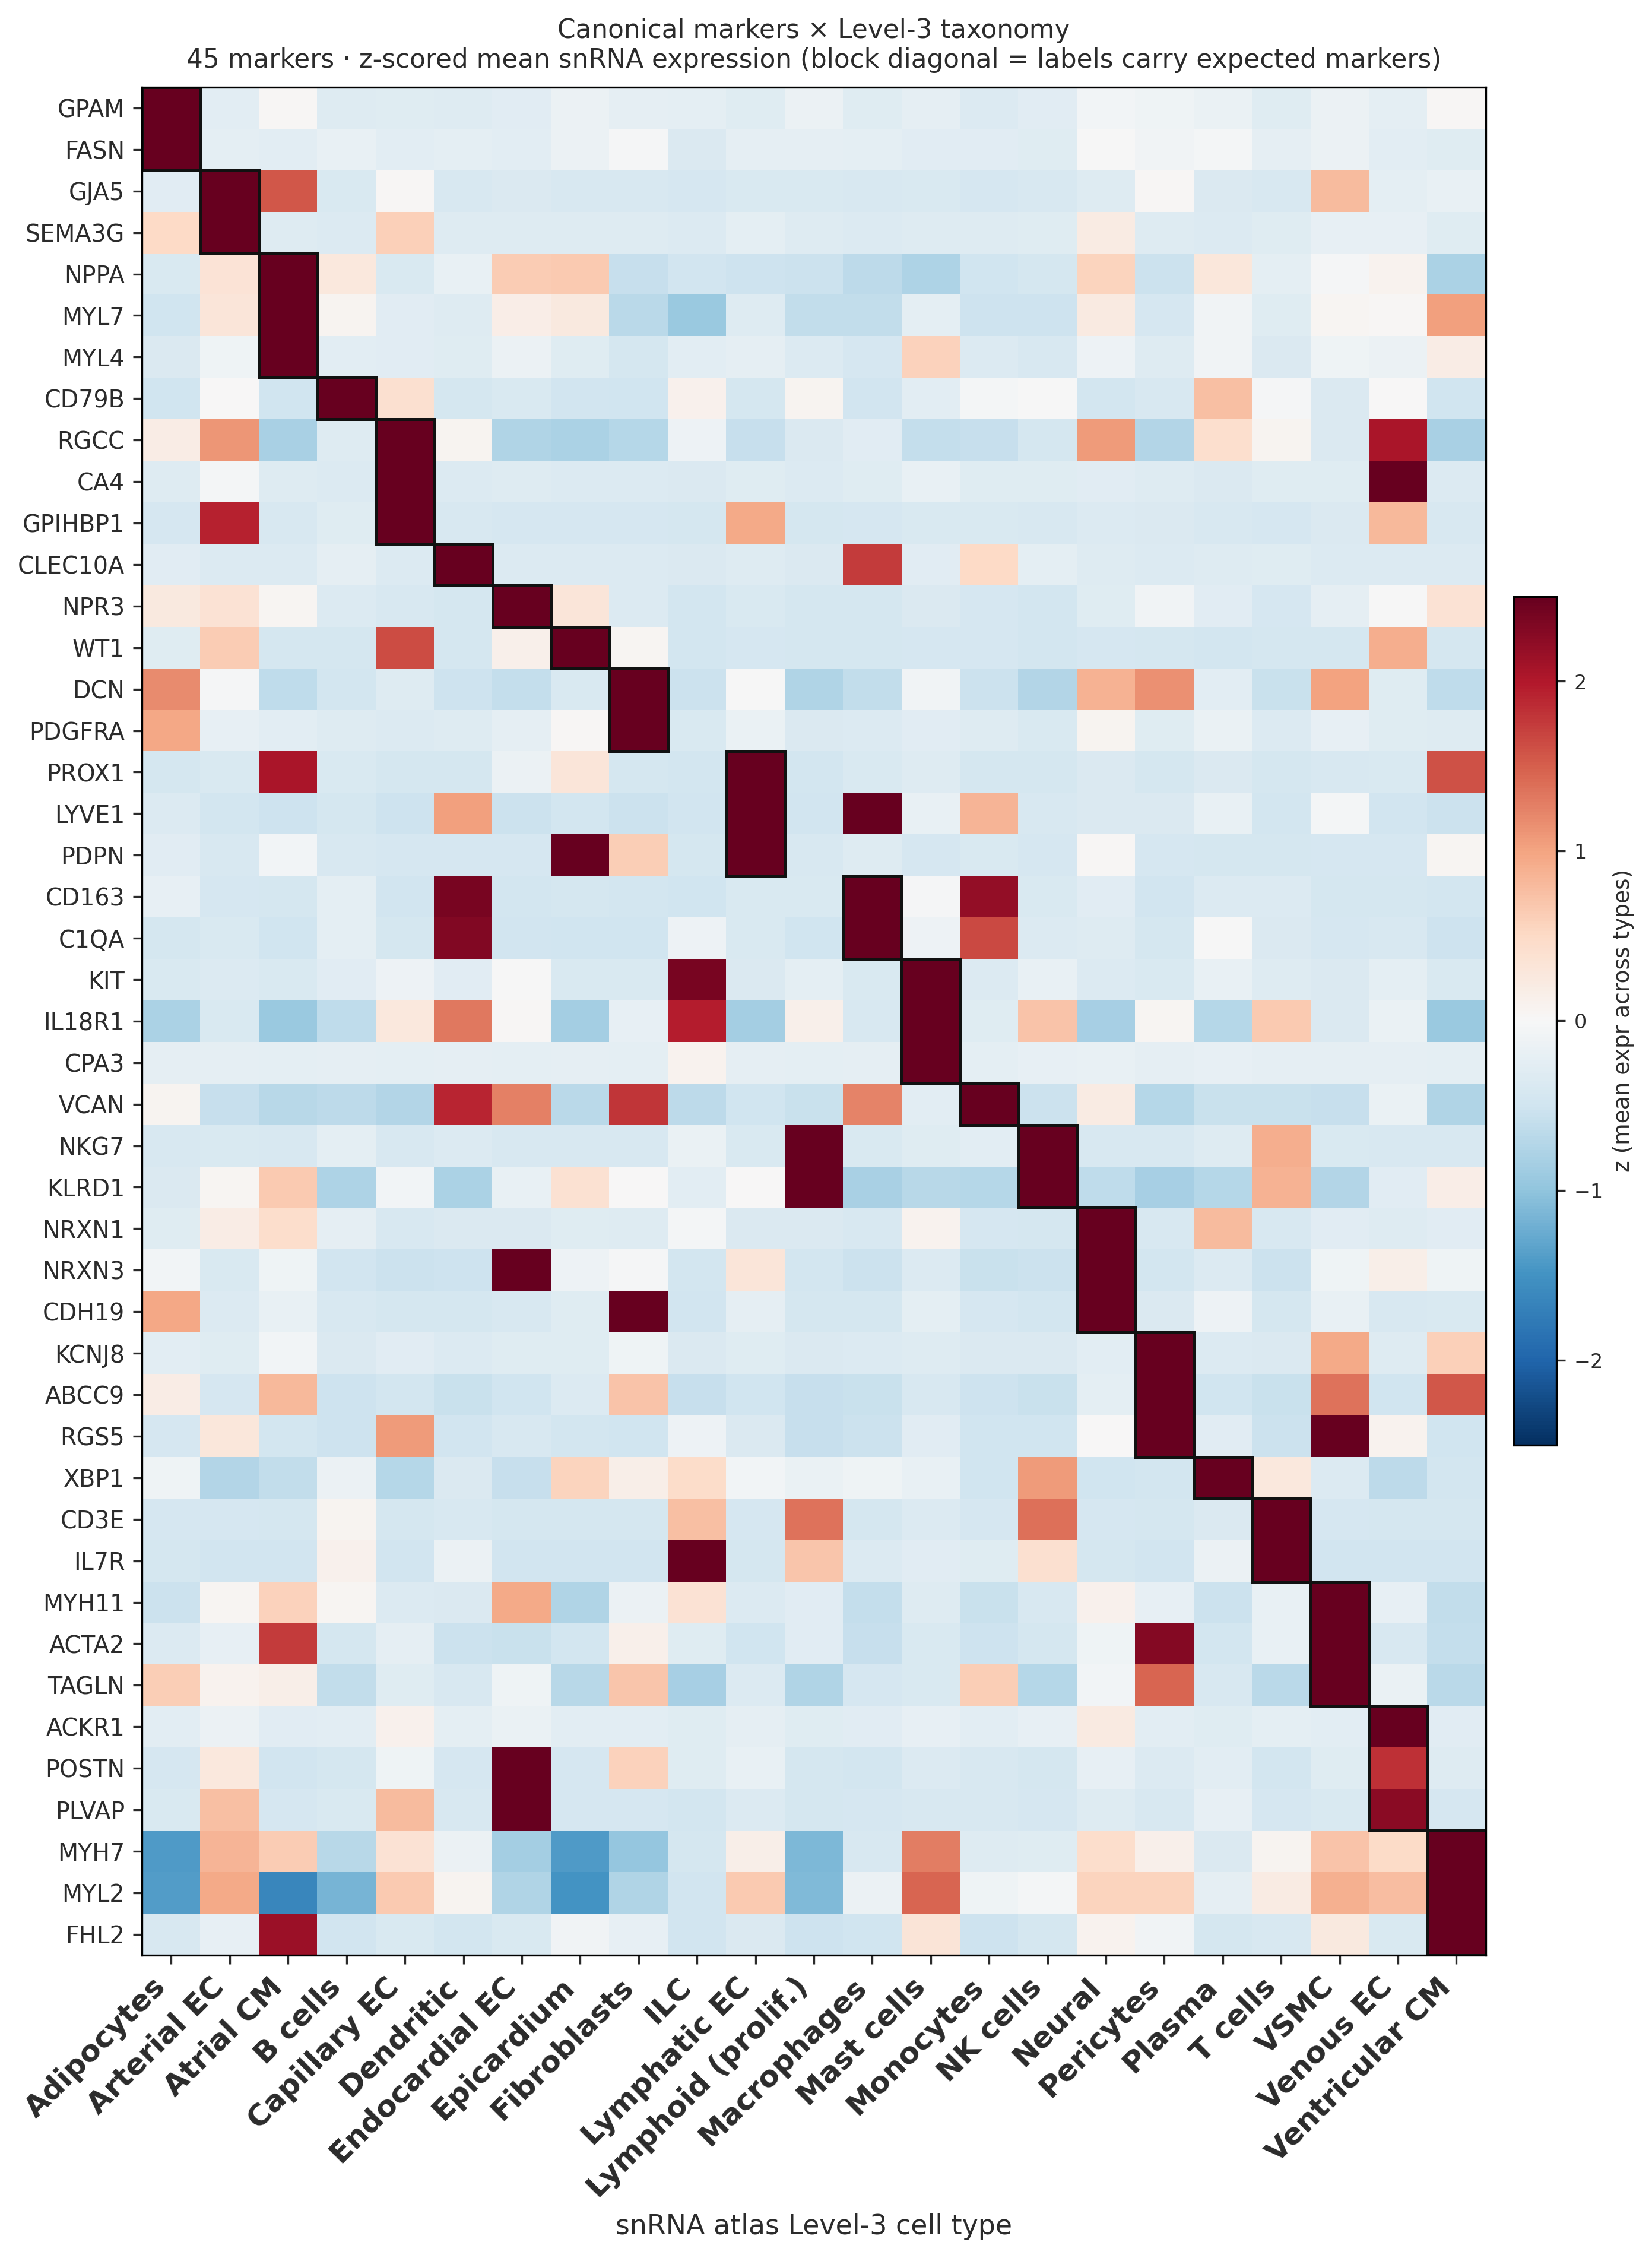

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
PSEUDOBULK = f"{TABLES}/heart_results/atlas_pseudobulk/mean_normcounts_L3.parquet"

SHORT = {"Ventricular Cardiomyocytes": "Ventricular CM", "Atrial Cardiomyocytes": "Atrial CM",
         "Vascular Smooth Muscle cells": "VSMC", "Arterial Endothelial cells": "Arterial EC",
         "Capillary Endothelial cells": "Capillary EC", "Venous Endothelial cells": "Venous EC",
         "Endocardial Endothelial Cells": "Endocardial EC",
         "Lymphatic Endothelial Cells": "Lymphatic EC",
         "Lymphoid Cells (Proliferating)": "Lymphoid (prolif.)", "Neural Cells": "Neural",
         "Plasma Cells": "Plasma", "Dendritic cells": "Dendritic"}

atlas = pd.read_parquet(PSEUDOBULK).drop(columns=["Unassigned"])
atlas.columns = [SHORT.get(c, c) for c in atlas.columns]
atlas = atlas[sorted(atlas.columns)]
LOGCP10K = np.log1p(atlas * 1e4 / atlas.sum(axis=0))

MARKER_BLOCKS = [
    ("Adipocytes", ["GPAM", "FASN"]), ("Arterial EC", ["GJA5", "SEMA3G"]),
    ("Atrial CM", ["NPPA", "MYL7", "MYL4"]), ("B cells", ["CD79B"]),
    ("Capillary EC", ["RGCC", "CA4", "GPIHBP1"]), ("Dendritic", ["CLEC10A"]),
    ("Endocardial EC", ["NPR3"]), ("Epicardium", ["WT1"]), ("Fibroblasts", ["DCN", "PDGFRA"]),
    ("Lymphatic EC", ["PROX1", "LYVE1", "PDPN"]), ("Macrophages", ["CD163", "C1QA"]),
    ("Mast cells", ["KIT", "IL18R1", "CPA3"]), ("Monocytes", ["VCAN"]),
    ("NK cells", ["NKG7", "KLRD1"]), ("Neural", ["NRXN1", "NRXN3", "CDH19"]),
    ("Pericytes", ["KCNJ8", "ABCC9", "RGS5"]), ("Plasma", ["XBP1"]), ("T cells", ["CD3E", "IL7R"]),
    ("VSMC", ["MYH11", "ACTA2", "TAGLN"]), ("Venous EC", ["ACKR1", "POSTN", "PLVAP"]),
    ("Ventricular CM", ["MYH7", "MYL2", "FHL2"]),
]
GENES = [g for _, genes in MARKER_BLOCKS for g in genes]
TYPES = list(atlas.columns)
expr = LOGCP10K.loc[GENES]
Z = expr.sub(expr.mean(axis=1), axis=0).div(expr.std(axis=1, ddof=0), axis=0)
print(f"{len(GENES)} markers x {len(TYPES)} types; z in [{Z.values.min():.2f}, {Z.values.max():.2f}]")

PAGE = (667.8949978221, 913.1558336047)
AXES = (57.371875, 122.3113026381, 543.217122931, 754.9726559666)
CBAR = (612.0, 328.5158336047, 17.28, 342.96)
W, HT = PAGE
plt.rcParams.update({
    "font.sans-serif": ["DejaVu Sans"], "savefig.pad_inches": 0.1,
    "xtick.major.size": 3.5, "ytick.major.size": 3.5,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "axes.linewidth": 0.8, "axes.edgecolor": "black",
    "axes.spines.top": True, "axes.spines.right": True,
})
fig = plt.figure(figsize=(W / 72, HT / 72))
ax = fig.add_axes([AXES[0] / W, AXES[1] / HT, AXES[2] / W, AXES[3] / HT])
im = ax.imshow(Z.values, cmap=H.DIVERGING, vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_yticks(range(len(GENES)))
ax.set_yticklabels(GENES, fontsize=9.5)
ax.set_xticks(range(len(TYPES)))
ax.set_xticklabels(TYPES, rotation=45, ha="right", fontsize=12, fontweight="bold")
ax.set_xlabel("snRNA atlas Level-3 cell type", fontsize=11)
ax.set_title("Canonical markers × Level-3 taxonomy\n"
             f"{len(GENES)} markers · z-scored mean snRNA expression "
             "(block diagonal = labels carry expected markers)", fontsize=10.5, pad=8)
row = 0
for t, genes in MARKER_BLOCKS:
    ax.add_patch(Rectangle((TYPES.index(t) - 0.5, row - 0.5), 1, len(genes),
                           fill=False, edgecolor="#111111", linewidth=1.2))
    row += len(genes)
cax = fig.add_axes([CBAR[0] / W, CBAR[1] / HT, CBAR[2] / W, CBAR[3] / HT])
cb = fig.colorbar(im, cax=cax)
cb.set_label("z (mean expr across types)", fontsize=9)
cb.ax.tick_params(labelsize=8)
print(save(fig, "ED6", "d"))


## ED6 F

ED6 F: whole-section atlas-guided FICTURE at 2 um with a 340 um vascular detail (port of figures/src/01_visiumhd/02b_wholeslide_ficture_map.py).

Input:
- `storage/Heart_ficture_2um_L3_h5ads/VS_CA_H0054LV_henricke_endo.h5ad`
- `storage/CMFLAG_fullmethod_realHE/VS_CA_H0054LV_henricke_endo_clean_bins.parquet`

Source: `figures/ED6/panel_f.py`

7,617,308 bins -> 6,587,499 retained (86.5%)


None


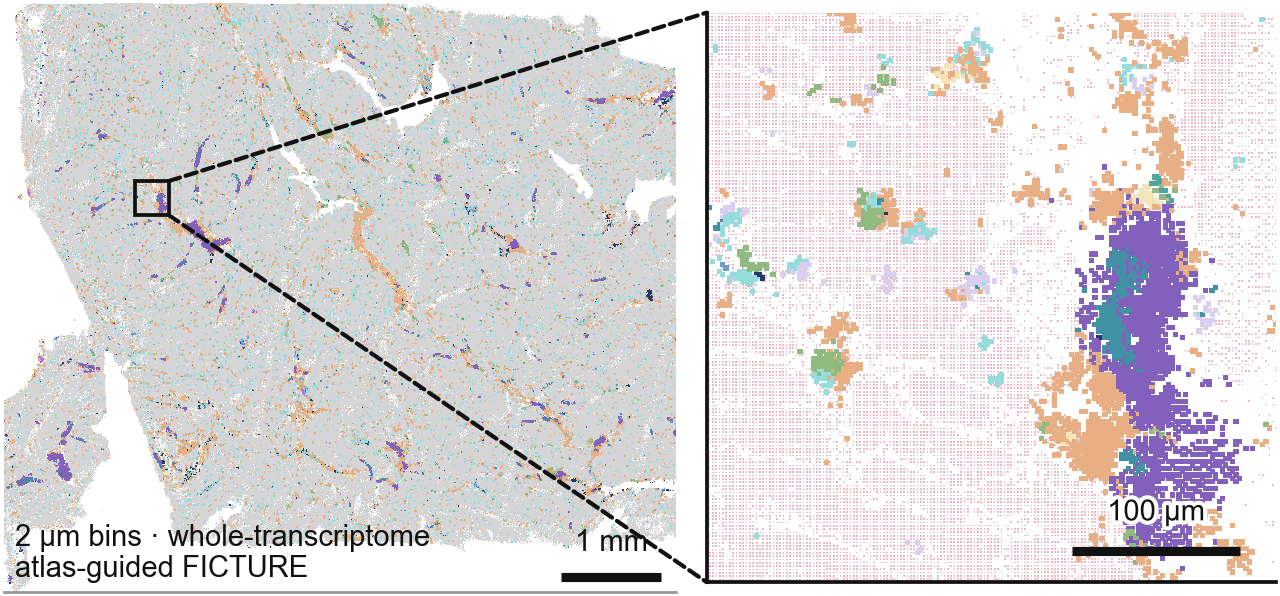

In [5]:
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Rectangle, ConnectionPatch

from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
plt.rcParams["savefig.pad_inches"] = 0.0125
SLIDE = "VS_CA_H0054LV_henricke_endo"
H5AD = f"{TABLES}/storage/Heart_ficture_2um_L3_h5ads/{SLIDE}.h5ad"
FLAGS = f"{TABLES}/storage/CMFLAG_fullmethod_realHE/{SLIDE}_clean_bins.parquet"
FLAGCOLS = ["flag_cm_spillover", "flag_vsmc_spillover", "flag_spill_artEC", "flag_spill_venEC"]
CM = ["Ventricular Cardiomyocytes", "Atrial Cardiomyocytes"]
CM_GREY = "#D5D5D5"
ZOOM_XY = (3194.0, 2767.0)
ZOOM_W = 340.0

adata = ad.read_h5ad(H5AD, backed="r")
obs = adata.obs[["x_um", "y_um", "L3_label"]].copy()
adata.file.close()
obs["L3"] = obs.L3_label.astype(str)


def bin_key(x, y):
    return np.round(x * 10).astype(np.int64) * 100_000_000 + np.round(y * 10).astype(np.int64)


flags = pd.read_parquet(FLAGS, columns=["X", "Y", "assign"] + FLAGCOLS)
flags["_k"] = bin_key(flags.X.to_numpy(), flags.Y.to_numpy())
per_bin = flags.groupby("_k", as_index=False).agg({**{c: "any" for c in FLAGCOLS}, "assign": "max"})
del flags
obs["_k"] = bin_key(obs.x_um.to_numpy(), obs.y_um.to_numpy())
obs = obs.merge(per_bin, on="_k", how="left")
obs[FLAGCOLS] = obs[FLAGCOLS].fillna(False).astype(bool)
obs["assign"] = obs["assign"].fillna(-1).astype(int)
spill = obs[FLAGCOLS].any(axis=1)
undecoded = obs["assign"] == -1
clean = obs.loc[~spill & ~undecoded].copy()
print(f"{len(obs):,} bins -> {len(clean):,} retained ({100 * len(clean) / len(obs):.1f}%)")

xs = clean.x_um.to_numpy(); ys = clean.y_um.to_numpy(); lab = clean.L3.to_numpy()
pal = {t: H.ct(t) for t in np.unique(lab)}
iscm = np.isin(lab, CM)
col = np.array([pal[t] for t in lab], dtype=object)
half = ZOOM_W / 2
zx0, zx1 = ZOOM_XY[0] - half, ZOOM_XY[0] + half
zy0, zy1 = ZOOM_XY[1] - half, ZOOM_XY[1] + half
zsel = (xs >= zx0) & (xs < zx1) & (ys >= zy0) & (ys < zy1)

fig = plt.figure(figsize=(4.276, 2.100))
axL = fig.add_axes([0.004, 0.007, 0.524, 0.936])
axR = fig.add_axes([0.552, 0.023, 0.444, 0.905])
axL.scatter(xs[iscm], ys[iscm], s=0.008, c=[CM_GREY] * int(iscm.sum()), linewidths=0, marker="s",
            rasterized=True)
axL.scatter(xs[~iscm], ys[~iscm], s=0.082, c=list(col[~iscm]), linewidths=0, marker="s", rasterized=True)
axL.set_aspect("equal")
axL.set_xlim(xs.min(), xs.max()); axL.set_ylim(ys.max(), ys.min())
axL.set_xticks([]); axL.set_yticks([])
for side, sp in axL.spines.items():
    sp.set_visible(side == "bottom"); sp.set_color("#9A9A9A"); sp.set_linewidth(0.68)
axL.add_patch(Rectangle((zx0, zy0), ZOOM_W, ZOOM_W, fill=False, edgecolor="#111111", lw=0.9, zorder=5))
axL.text(0.016, 0.0165, "2 µm bins · whole-transcriptome\natlas-guided FICTURE", transform=axL.transAxes,
         ha="left", va="bottom", fontsize=7.0, color="#111111", linespacing=1.15)
bar = 1000.0
bx = xs.max() - bar - 0.022 * (xs.max() - xs.min())
by = ys.max() - 0.026 * (ys.max() - ys.min())
axL.plot([bx, bx + bar], [by, by], color="#111111", lw=2.2, solid_capstyle="butt")
axL.text(bx + bar / 2, by - 0.035 * (ys.max() - ys.min()), "1 mm", ha="center", va="bottom", fontsize=7.0,
         color="#111111")

zcm = iscm[zsel]
axR.scatter(xs[zsel][zcm], ys[zsel][zcm], s=0.17, c=list(col[zsel][zcm]), linewidths=0, marker="s",
            rasterized=True)
axR.scatter(xs[zsel][~zcm], ys[zsel][~zcm], s=1.6, c=list(col[zsel][~zcm]), linewidths=0, marker="s",
            rasterized=True)
axR.set_aspect("equal")
axR.set_xlim(zx0, zx1); axR.set_ylim(zy1, zy0)
axR.set_xticks([]); axR.set_yticks([])
for side, sp in axR.spines.items():
    sp.set_visible(side in ("left", "bottom")); sp.set_color("#111111"); sp.set_linewidth(0.9)
zbar = 100.0
zbx = zx1 - zbar - 0.064 * ZOOM_W
zby = zy1 - 0.055 * ZOOM_W
axR.plot([zbx, zbx + zbar], [zby, zby], color="#111111", lw=2.2, solid_capstyle="butt")
axR.text(zbx + zbar / 2, zby - 0.043 * ZOOM_W, "100 µm", ha="center", va="bottom", fontsize=7.0,
         color="#111111", path_effects=[pe.withStroke(linewidth=2.0, foreground="white")])
for (dx, dy), (rx, ry) in [((zx1, zy0), (0, 1)), ((zx1, zy1), (0, 0))]:
    fig.add_artist(ConnectionPatch(xyA=(dx, dy), coordsA=axL.transData, xyB=(rx, ry), coordsB=axR.transAxes,
                                   color="#111111", lw=1.0, ls=(0, (2.8, 1.4))))
print(save(fig, "ED6", "f", dpi=400))


## ED6 H

ED6 H: cohort-mean cell-type composition per deconvolution method (port of figures/src/02_visium/01_deconvolution_benchmark.py).

Input:
- `scanpy_analysis/standard_visium/deconv_benchmark/tables/composition_mean_by_method.csv`

Source: `figures/ED6/panel_h.py`

None


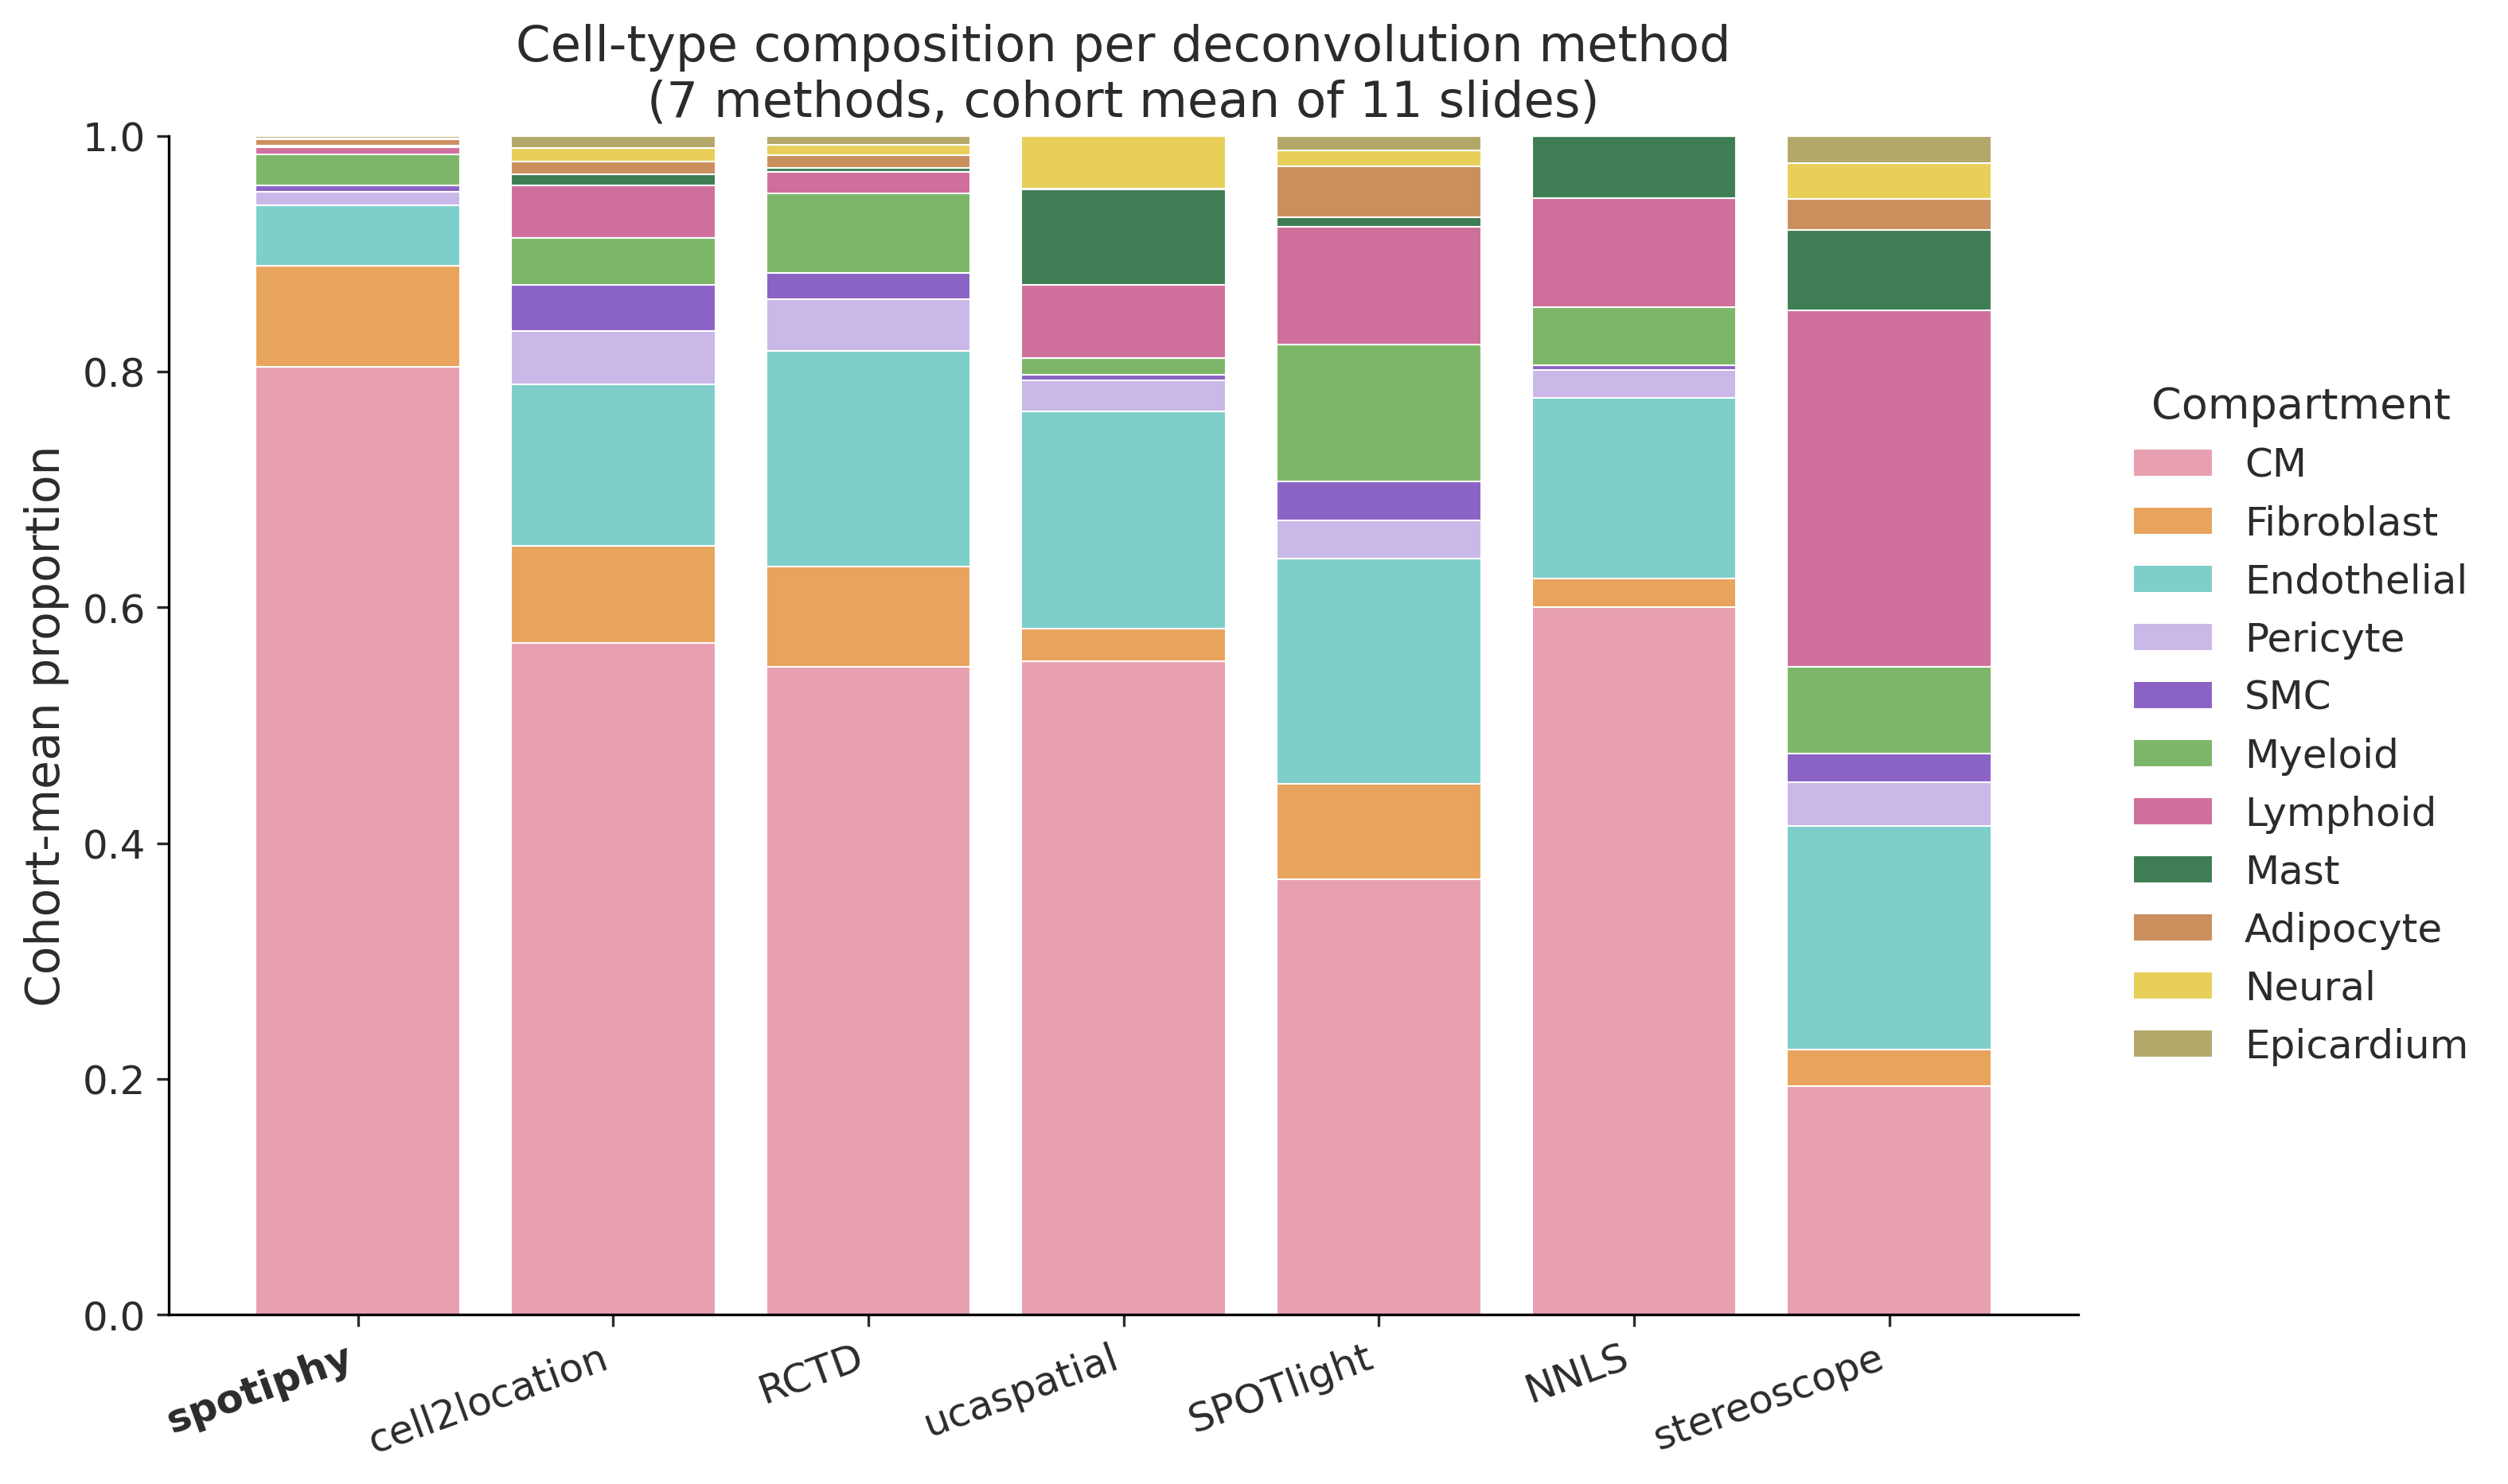

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
BENCH = f"{TABLES}/scanpy_analysis/standard_visium/deconv_benchmark"
comp = pd.read_csv(f"{BENCH}/tables/composition_mean_by_method.csv", index_col=0)

WINNER = "spotiphy"
CP_PAGE = (756.094452, 453.15664)
CP_AXES = (50.840625, 54.1400399049, 575.6752, 355.6322248317)
COMP_ORDER = ["CM", "Fibroblast", "Endothelial", "Pericyte", "SMC", "Myeloid",
              "Lymphoid", "Mast", "Adipocyte", "Neural", "Epicardium"]
COMP_COLOR = {"CM": "#E8A0B0", "Fibroblast": "#E8A45C", "Endothelial": "#7ECECA",
              "Pericyte": "#C9B8E8", "SMC": "#8A63C4", "Myeloid": "#7CB668",
              "Lymphoid": "#CF6F9B", "Mast": "#3F7D54", "Adipocyte": "#CB8F5E",
              "Neural": "#E8CF5A", "Epicardium": "#B3A86A"}
METHOD_ORDER = ["spotiphy", "cell2location", "RCTD", "ucaspatial", "SPOTlight", "NNLS", "stereoscope"]

C = comp.reindex(index=METHOD_ORDER, columns=COMP_ORDER)
W, HT = CP_PAGE
plt.rcParams.update({
    "font.sans-serif": ["DejaVu Sans"], "savefig.pad_inches": 0.1,
    "legend.labelspacing": 0.5, "legend.handlelength": 2.0,
    "legend.handletextpad": 0.8, "legend.borderpad": 0.4,
    "xtick.major.size": 3.5, "ytick.major.size": 3.5,
    "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "axes.linewidth": 0.8, "axes.edgecolor": "black",
})
fig = plt.figure(figsize=(W / 72, HT / 72))
ax = fig.add_axes([CP_AXES[0] / W, CP_AXES[1] / HT, CP_AXES[2] / W, CP_AXES[3] / HT])
x = np.arange(len(C))
bottom = np.zeros(len(C))
for c in COMP_ORDER:
    ax.bar(x, C[c].values, bottom=bottom, width=0.8, color=COMP_COLOR[c],
           edgecolor="white", linewidth=0.5, label=c)
    bottom += C[c].values
ax.set_xticks(x)
ax.set_xticklabels(C.index, rotation=20, ha="right", fontsize=13)
for t, m in zip(ax.get_xticklabels(), C.index):
    if m == WINNER:
        t.set_fontweight("bold")
ax.set_ylabel("Cohort-mean proportion", fontsize=14)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.tick_params(labelsize=12)
ax.set_title("Cell-type composition per deconvolution method\n"
             "(7 methods, cohort mean of 11 slides)", fontsize=15, pad=6)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=12, frameon=False,
          title="Compartment", title_fontsize=13)
print(save(fig, "ED6", "h"))


## ED6 I

ED6 I: healthy Xenium section coloured by CellPin label, with vascular zoom (port of figures/src/03_xenium/01_annotation_and_transfer.py).

Input:
- `scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin/annotation/xenium_annotated.h5ad`
- `scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin/annotation/xenium_annotated_v1old.h5ad`
- `scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin/cellpin_imputed_full.h5ad`

Source: `figures/ED6/panel_i.py`

26,366 cells; classes: ['Ventricular CM', 'Fibroblasts', 'Atrial CM', 'Myeloid (macrophage)', 'Pericytes', 'Capillary EC', 'Venous EC', 'Arterial EC', 'Neural', 'Smooth muscle', 'T / NK (lymphoid)', 'Adipocytes', 'B cells', 'Mast cells', 'Lymphatic EC']


None


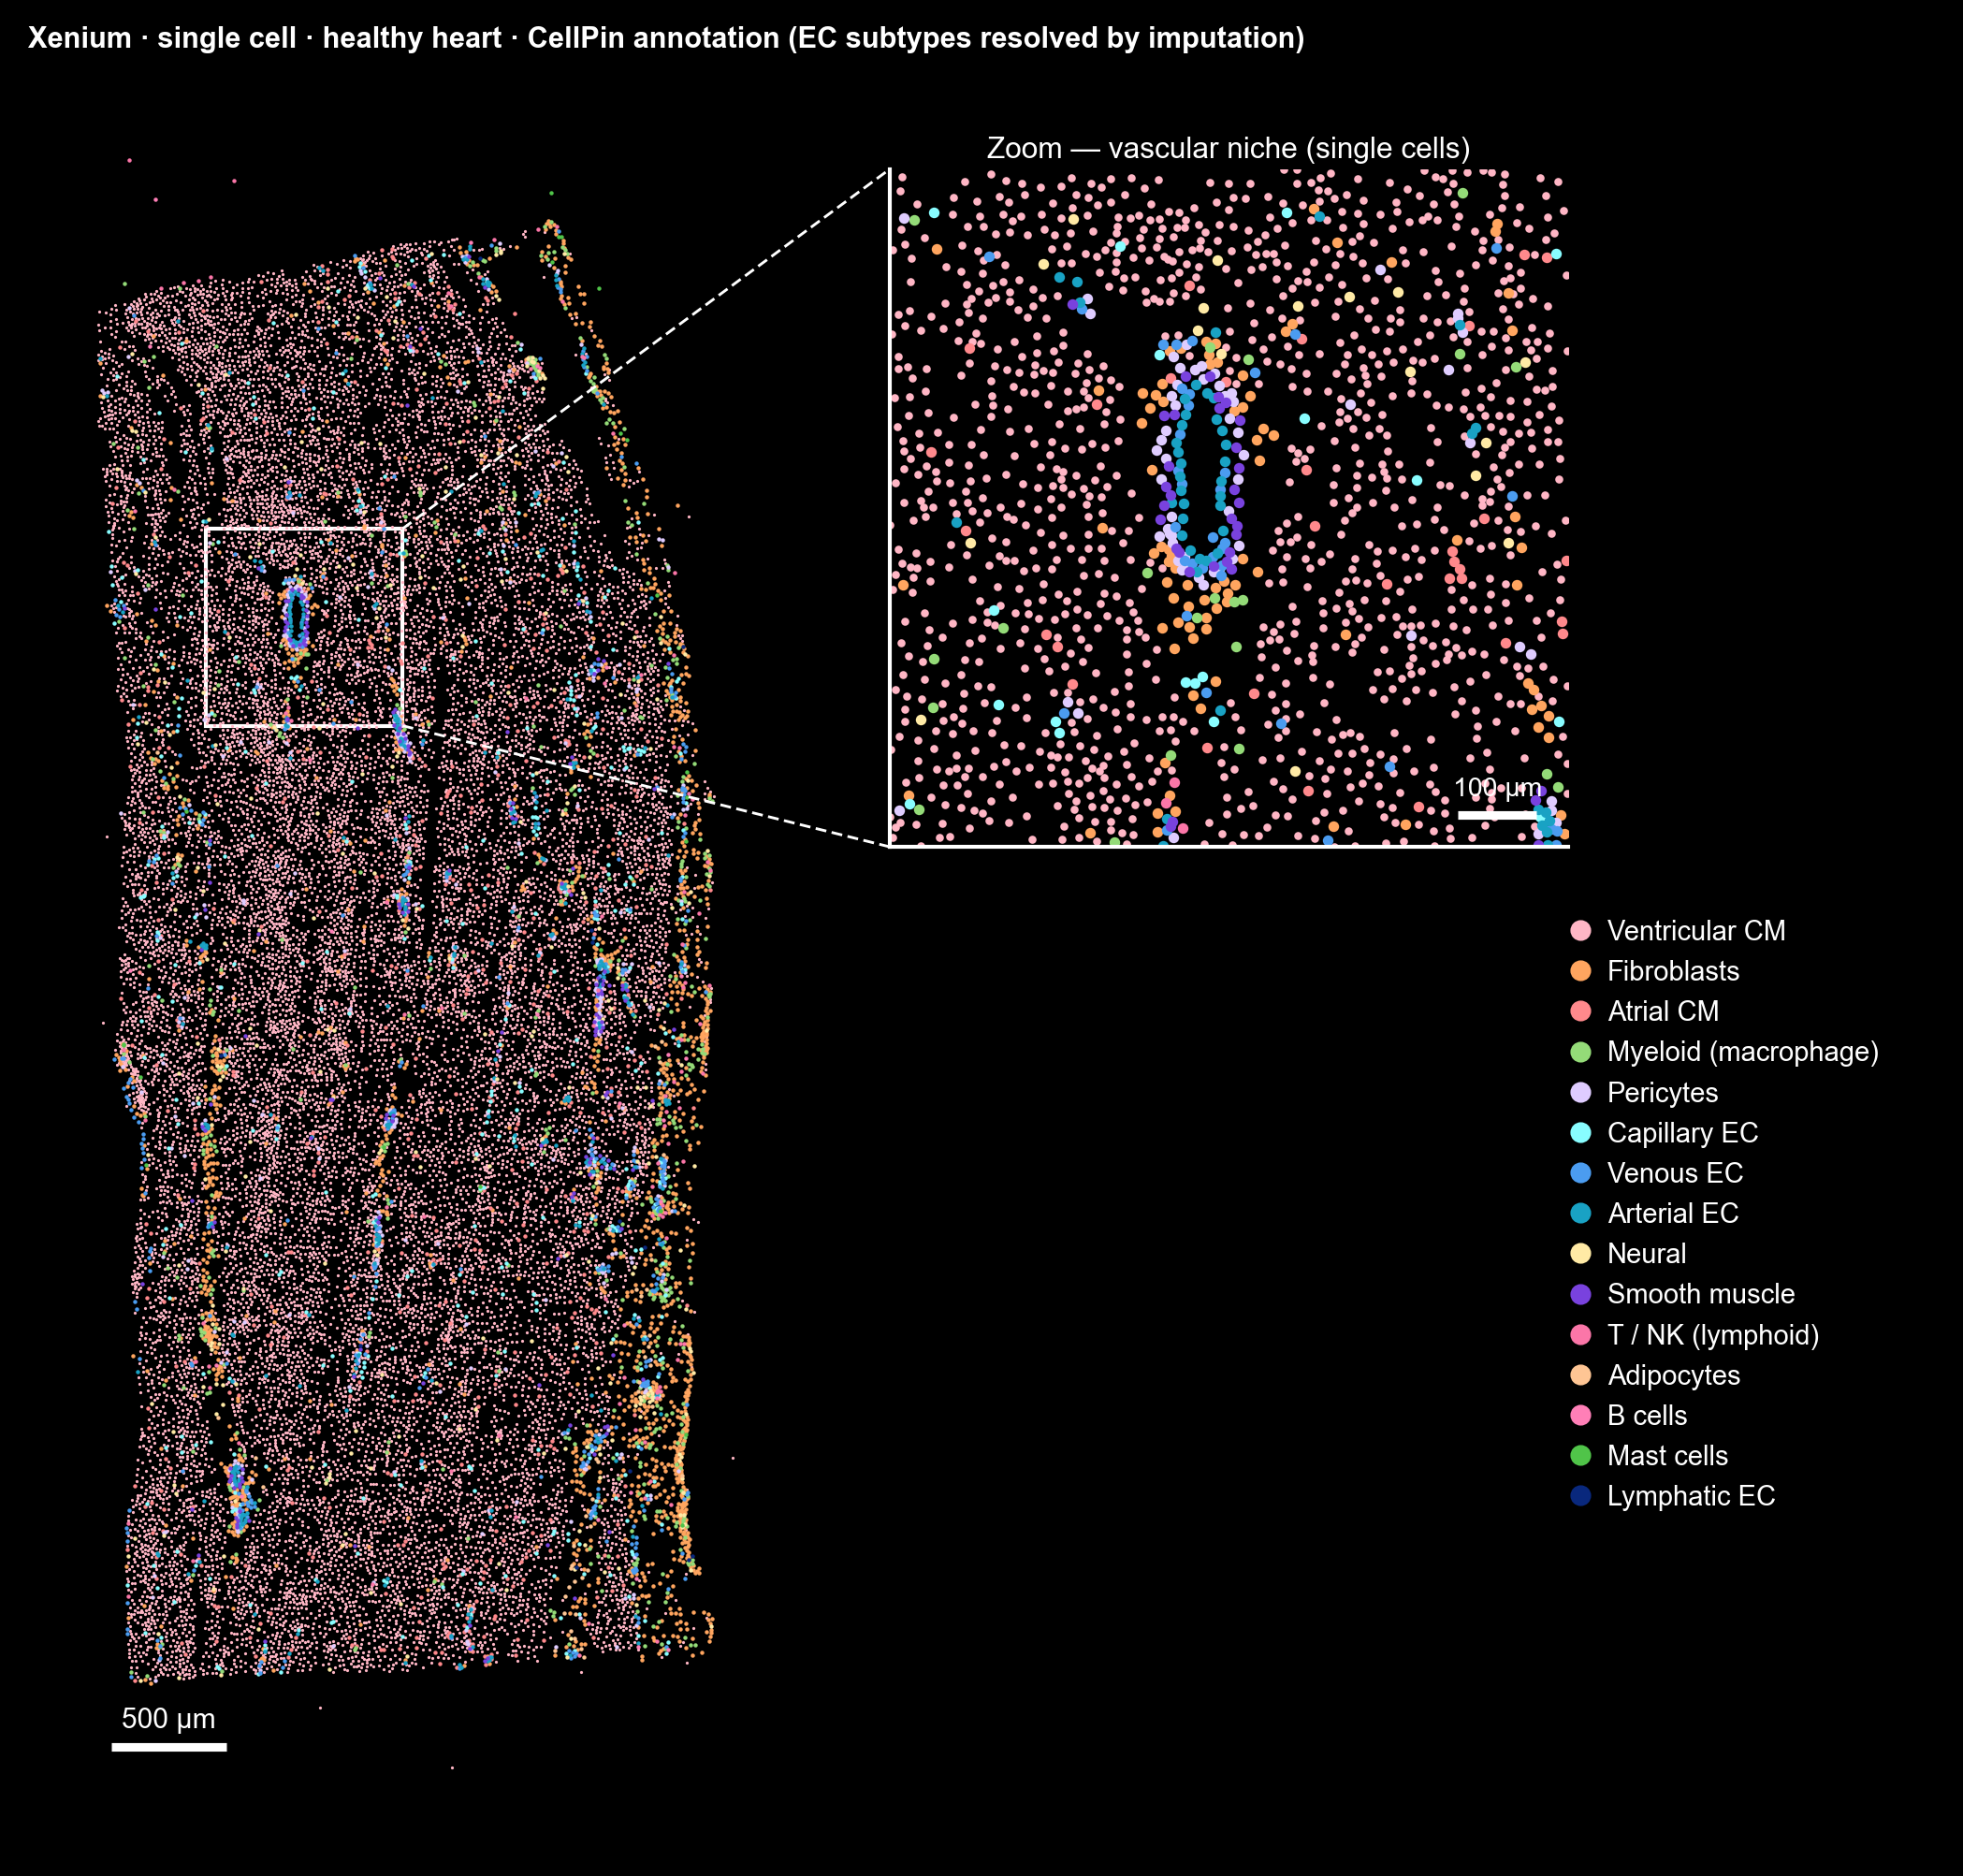

In [7]:
import colorsys

import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

from hhca.paths import TABLES
from hhca import style as H
from pubfig import save

H.apply()
CELLPIN = f"{TABLES}/scanpy_analysis/xenium/Xenium_V1_hHeart_nondiseased_section_FFPE/cellpin"

xa = ad.read_h5ad(f"{CELLPIN}/annotation/xenium_annotated.h5ad", backed="r")
xy = np.asarray(xa.obsm["spatial"], float)
xa.file.close()
xv = ad.read_h5ad(f"{CELLPIN}/annotation/xenium_annotated_v1old.h5ad", backed="r")
fine = xv.obs.cellpin_fine.astype(str).to_numpy()
xv.file.close()

# endothelium split on the imputed transcriptome (the published arterial/venous call is lost; see notebook)
EC_MARKERS = {"Arterial EC": ["GJA5", "SEMA3G", "HEY1", "DKK2"],
              "Capillary EC": ["RGCC", "CA4", "GPIHBP1", "CD36"],
              "Venous EC": ["ACKR1", "NR2F2", "PLVAP", "VCAM1"]}
is_ec = np.isin(fine, ["EndothelialCells", "EndocardialCells"])
imp = ad.read_h5ad(f"{CELLPIN}/cellpin_imputed_full.h5ad")
cols = [imp.var_names.get_loc(g) for gs in EC_MARKERS.values() for g in gs]
sub = imp.layers["imputed_norm"][is_ec][:, cols]
sub = np.asarray(sub.todense()) if hasattr(sub, "todense") else np.asarray(sub)
genes = [g for gs in EC_MARKERS.values() for g in gs]
del imp
zs = (sub - sub.mean(0)) / (sub.std(0) + 1e-9)
ec_score = pd.DataFrame({k: zs[:, [genes.index(g) for g in gs]].mean(1) for k, gs in EC_MARKERS.items()})

DISPLAY = {
    "VentricularCardiomyocytes": ("Ventricular CM", "Ventricular Cardiomyocytes"),
    "Fibroblasts": ("Fibroblasts", "Fibroblasts"),
    "AtrialCardiomyocytes": ("Atrial CM", "Atrial Cardiomyocytes"),
    "MyeloidCells": ("Myeloid (macrophage)", "Macrophages"),
    "Pericytes": ("Pericytes", "Pericytes"),
    "NeuralCells": ("Neural", "Neural Cells"),
    "SmoothMuscleCells": ("Smooth muscle", "Vascular Smooth Muscle cells"),
    "LymphoidCellsNonB": ("T / NK (lymphoid)", "T cells"),
    "Adipocytes": ("Adipocytes", "Adipocytes"),
    "LymphoidCellsB": ("B cells", "B cells"),
    "MastCells": ("Mast cells", "Mast cells"),
    "LymphaticEndothelialCells": ("Lymphatic EC", "Lymphatic Endothelial Cells"),
    "Arterial EC": ("Arterial EC", "Arterial Endothelial cells"),
    "Capillary EC": ("Capillary EC", "Capillary Endothelial cells"),
    "Venous EC": ("Venous EC", "Venous Endothelial cells"),
}
PAGE = (503.748, 481.3632)
AX_MAIN = (17.0017334906, 7.2, 179.1165330187, 453.456)
AX_ZOOM = (228.276, 263.97, 173.88, 173.88)
ROI_PT = (52.74848, 295.052365, 103.259915, 345.5638)
BAR_MAIN_PT = (28.667448, 58.034561, 33.097717)
BAR_ZOOM_PT = (373.849953, 394.068558, 272.057442)
LEGEND_PT = (400.372, 246.856)
S_MAIN = (0.6, 1.15)
S_ZOOM = (4.25, 7.5)
LEGEND_MS, LEGEND_SPACING = 4.32, 0.52


def on_dark(hex_colour, sat=1.45, val=1.18):
    r, g, b = (int(hex_colour[i:i + 2], 16) / 255 for i in (1, 3, 5))
    h, s, v = colorsys.rgb_to_hsv(r, g, b)
    return colorsys.hsv_to_rgb(h, min(1.0, s * sat), min(1.0, v * val))


label = np.array([DISPLAY[f][0] if f in DISPLAY else f for f in fine], dtype=object)
label[is_ec] = ec_score.idxmax(axis=1).to_numpy()
palette = {short: on_dark(H.ct(full)) for short, full in DISPLAY.values()}
order = list(pd.Series(label).value_counts().index)
member = {t: label == t for t in order}
print(f"{len(label):,} cells; classes: {order}")


def dot(ax, t, mask, sizes):
    area = sizes[0] if t == order[0] else sizes[1]
    ax.plot(xy[mask, 0], xy[mask, 1], marker="o", ls="", ms=area ** 0.5, mfc=palette[t], mec="none",
            rasterized=True)


W, HT = PAGE
mx, my = 0.05 * np.ptp(xy[:, 0]), 0.05 * np.ptp(xy[:, 1])
XLIM = (xy[:, 0].min() - mx, xy[:, 0].max() + mx)
YLIM = (xy[:, 1].max() + my, xy[:, 1].min() - my)
PT_PER_UM = AX_MAIN[2] / (XLIM[1] - XLIM[0])


def to_data(x_pt, y_pt):
    return XLIM[0] + (x_pt - AX_MAIN[0]) / PT_PER_UM, YLIM[0] - (y_pt - AX_MAIN[1]) / PT_PER_UM


rx0, ry1 = to_data(ROI_PT[0], ROI_PT[1])
rx1, ry0 = to_data(ROI_PT[2], ROI_PT[3])
in_roi = (xy[:, 0] >= rx0) & (xy[:, 0] <= rx1) & (xy[:, 1] >= ry0) & (xy[:, 1] <= ry1)

plt.rcParams.update({"savefig.pad_inches": 0.0, "legend.handlelength": 1.0, "savefig.bbox": None})
fig = plt.figure(figsize=(W / 72, HT / 72), facecolor="black")
fig.patches.append(Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor="black",
                             edgecolor="none", zorder=-10))
ax = fig.add_axes([AX_MAIN[0] / W, AX_MAIN[1] / HT, AX_MAIN[2] / W, AX_MAIN[3] / HT], facecolor="black")
for t in order:
    dot(ax, t, member[t], S_MAIN)
ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
ax.add_patch(Rectangle((rx0, ry0), rx1 - rx0, ry1 - ry0, fill=False, edgecolor="white", linewidth=1.0))
bx0, by = to_data(BAR_MAIN_PT[0], BAR_MAIN_PT[2])
bx1, _ = to_data(BAR_MAIN_PT[1], BAR_MAIN_PT[2])
ax.plot([bx0, bx1], [by, by], color="white", lw=2.2, solid_capstyle="butt")
fig.text(31.187 / W, 38.012 / HT, "500 µm", color="white", fontsize=7.2, ha="left", va="baseline")

az = fig.add_axes([AX_ZOOM[0] / W, AX_ZOOM[1] / HT, AX_ZOOM[2] / W, AX_ZOOM[3] / HT], facecolor="black")
for t in order:
    dot(az, t, member[t] & in_roi, S_ZOOM)
az.set_xlim(rx0, rx1); az.set_ylim(ry1, ry0)
az.set_xticks([]); az.set_yticks([])
for name in ("top", "right"):
    az.spines[name].set_visible(False)
for name in ("left", "bottom"):
    az.spines[name].set_color("white"); az.spines[name].set_linewidth(1.0)
az.set_title("Zoom — vascular niche (single cells)", color="white", fontsize=7.6, pad=3.0)
zk = AX_ZOOM[2] / (rx1 - rx0)
zx0 = rx0 + (BAR_ZOOM_PT[0] - AX_ZOOM[0]) / zk
zx1 = rx0 + (BAR_ZOOM_PT[1] - AX_ZOOM[0]) / zk
zy = ry1 - (BAR_ZOOM_PT[2] - AX_ZOOM[1]) / zk
az.plot([zx0, zx1], [zy, zy], color="white", lw=2.2, solid_capstyle="butt")
fig.text(372.639 / W, 277.087 / HT, "100 µm", color="white", fontsize=6.8, ha="left", va="baseline")
for y_roi, y_zoom in ((ROI_PT[1], AX_ZOOM[1]), (ROI_PT[3], AX_ZOOM[1] + AX_ZOOM[3])):
    fig.add_artist(Line2D([ROI_PT[2] / W, AX_ZOOM[0] / W], [y_roi / HT, y_zoom / HT],
                          transform=fig.transFigure, color="white", lw=0.7, ls=(0, (4, 2)),
                          solid_capstyle="round"))
fig.text(7.2 / W, 469.06945 / HT,
         "Xenium · single cell · healthy heart · CellPin annotation (EC subtypes resolved by imputation)",
         color="white", fontsize=7.4, fontweight="bold", ha="left", va="baseline")
fig.legend(handles=[Line2D([], [], marker="o", ls="", ms=LEGEND_MS, color=palette[t], label=t) for t in order],
           loc="upper left", bbox_to_anchor=(LEGEND_PT[0] / W, LEGEND_PT[1] / HT), frameon=False,
           fontsize=7, labelcolor="white", labelspacing=LEGEND_SPACING, borderaxespad=0.0)
print(save(fig, "ED6", "i", dpi=400, facecolor="black"))
